In [1]:
import numpy  as np
import pandas as pd
import re,os,sys

In [2]:
path = r"LMD_PancreaticCancer_Quant_Spectranout_RAW_log2-mcpcounter-sigmtx_Joe3_nodup.tsv"

In [3]:
data = pd.read_csv(path,sep="\t")

In [4]:
data

,Unnamed: 0,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
0,Acinar,732.101853,592.219502,777.811746,654.557598,782.306694,702.365258,808.318370,751.467651,859.709123,...,945.573599,782.259260,751.634681,620.767038,758.737395,828.637784,661.728912,861.528702,828.099734,805.365161
1,Epithelial_cancer,1123.746865,945.271559,1191.484247,1032.667093,1322.629987,1186.689042,1271.936465,1299.993143,1270.237963,...,1504.692122,1475.255400,1502.699403,845.889039,1097.651288,1125.965640,966.685498,987.068518,1017.820575,946.282599
2,Epithelial_normal,357.471070,294.751280,363.942880,308.118657,392.124829,408.362349,415.066607,333.116169,333.857065,...,493.368395,784.918804,747.536572,620.585057,611.226510,761.549466,458.060181,1016.985054,1158.692691,918.766156
3,Fibroblast,1146.143984,943.461405,1205.825384,652.231860,1062.018701,1130.809794,928.027587,912.507659,583.582485,...,514.359694,574.125667,522.013357,561.887559,828.390331,760.389981,567.144594,991.710867,1095.363122,867.728044


In [5]:
df = pd.DataFrame(data).set_index("Unnamed: 0") 

df_percentage = df.div(df.sum(axis=0), axis=1) * 100

In [6]:
df_percentage

,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,008_PDAC_2,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Acinar,21.792223,21.335832,21.977893,24.722909,21.980586,20.487715,23.611918,22.791882,28.211357,21.757697,...,27.344572,21.629931,21.329722,23.432876,23.019907,23.835109,24.936845,22.335059,20.197672,22.762376
Epithelial_cancer,33.450186,34.055203,33.666646,39.004259,37.162129,34.615247,37.154741,39.428565,41.682862,48.668463,...,43.513442,40.791685,42.643271,31.930840,33.302471,32.387509,36.428946,25.589668,24.825037,26.745185
Epithelial_normal,10.640718,10.618975,10.283591,11.637768,11.017589,11.911767,12.124578,10.103355,10.955520,11.649833,...,14.267475,21.703469,21.213427,23.426006,18.544463,21.905367,17.261715,26.365252,28.260962,25.967476
Fibroblast,34.116873,33.989989,34.071870,24.635064,29.839696,32.985271,27.108763,27.676198,19.150261,17.924007,...,14.874512,15.874914,14.813579,21.210278,25.133160,21.872015,21.372494,25.710021,26.716329,24.524964


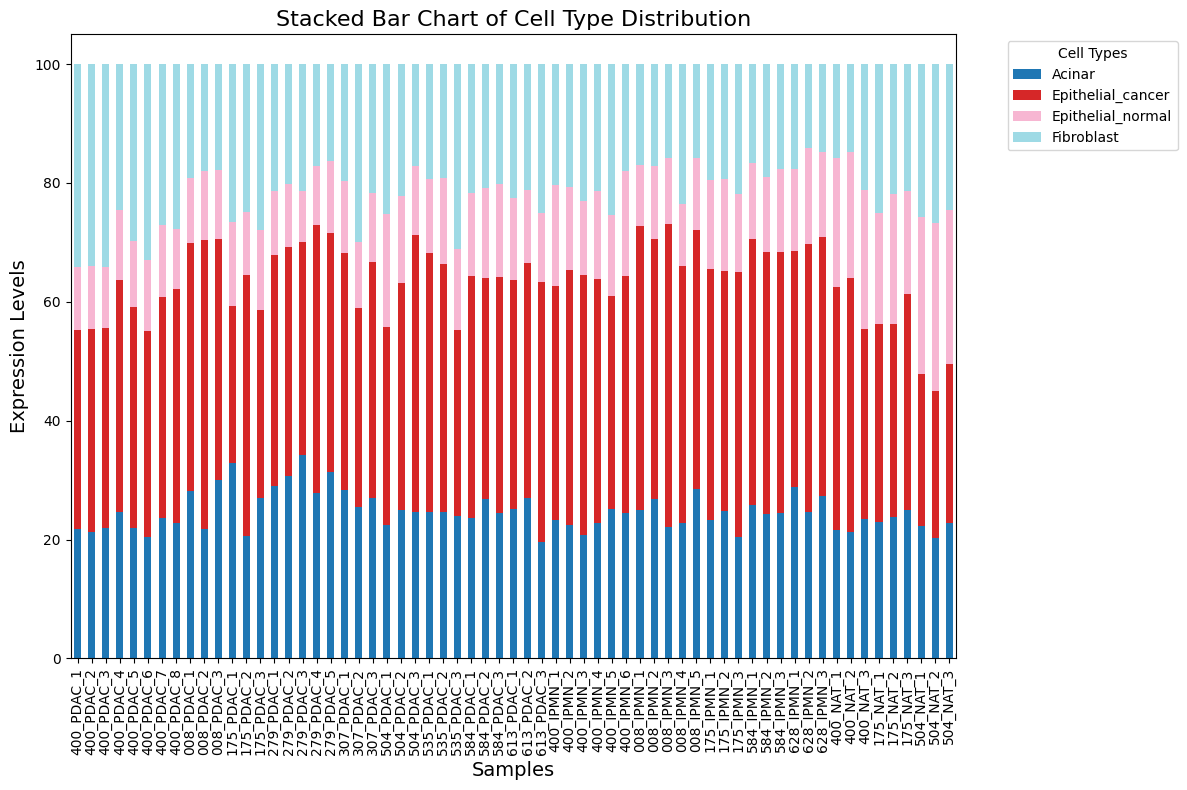

In [7]:
# Convert to a DataFrame
import matplotlib.pyplot as plt


# Create a stacked bar chart
df_percentage.T.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
plt.title("Stacked Bar Chart of Cell Type Distribution", fontsize=16)
plt.xlabel("Samples", fontsize=14)
plt.ylabel("Expression Levels", fontsize=14)
plt.legend(title="Cell Types", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
# Assuming `df_percentage` contains your percentage-normalized data
pca = PCA(n_components=2)  # Choose the number of components you want
pca_result = pca.fit_transform(df_percentage.T)  # Transpose to analyze samples


In [10]:
pca_df = pd.DataFrame(
    pca_result, columns=['PC1', 'PC2'], index=df_percentage.columns
)


In [11]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance: {explained_variance}")


Explained Variance: [0.59093064 0.25854548]


In [12]:
pca_df.head(2)

,PC1,PC2
400_PDAC_1,-10.579731,-9.084408
400_PDAC_2,-10.086553,-9.132879


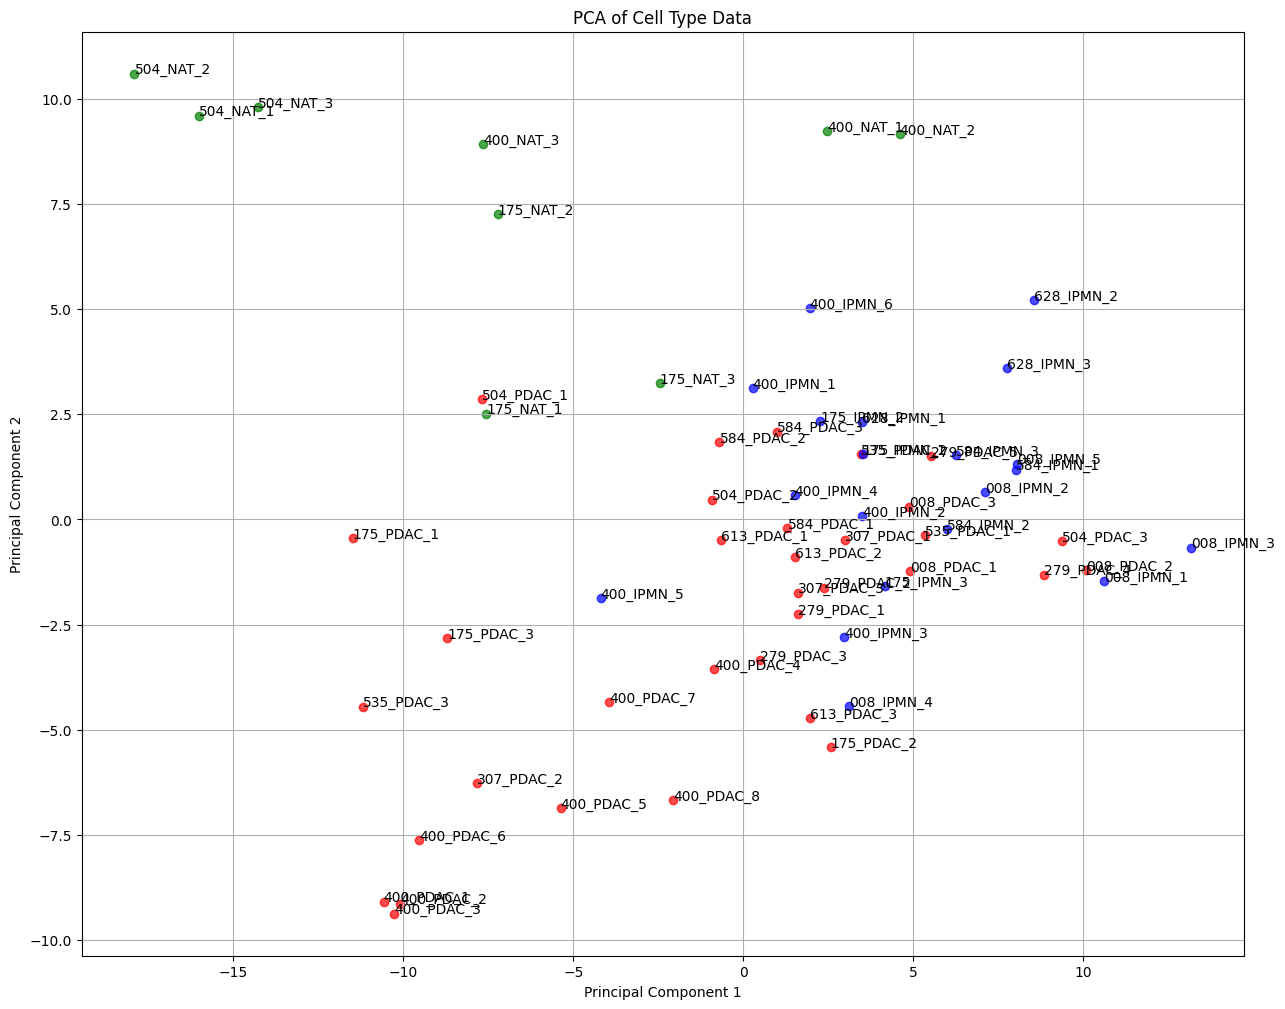

In [13]:
plt.figure(figsize=(15, 12))
plt.scatter(pca_df[pca_df.index.str.contains('PDAC')]['PC1'], pca_df[pca_df.index.str.contains('PDAC')]['PC2'], c='red', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('IPMN')]['PC1'], pca_df[pca_df.index.str.contains('IPMN')]['PC2'], c='blue', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('NAT')]['PC1'], pca_df[pca_df.index.str.contains('NAT')]['PC2'], c='green', alpha=0.7)
for sample, (x, y) in pca_df.iterrows():
    plt.text(x, y, sample, fontsize=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Cell Type Data')
plt.grid()
plt.show()


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose to align features with PCs
    index=df_percentage.index,  # Feature names (cell types)
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]  # PC names
)
print(loadings)


                        PC1       PC2
Unnamed: 0                           
Acinar             0.099925  0.003112
Epithelial_cancer  0.758862 -0.176483
Epithelial_normal -0.278753  0.777271
Fibroblast        -0.580034 -0.603899


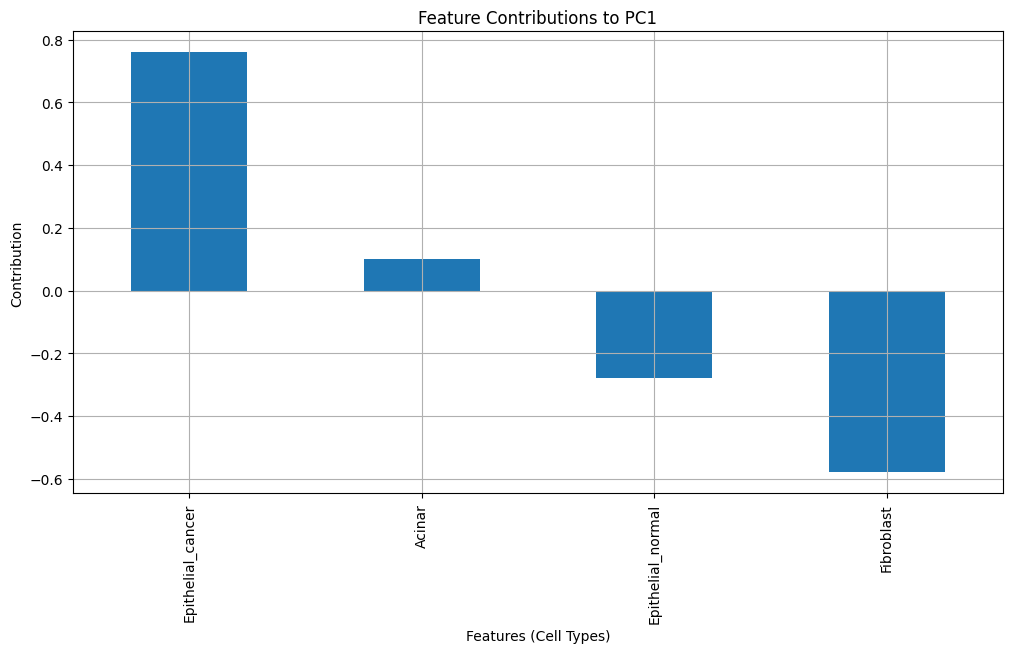

In [15]:
plt.figure(figsize=(12, 6))
loadings['PC1'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC1')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()


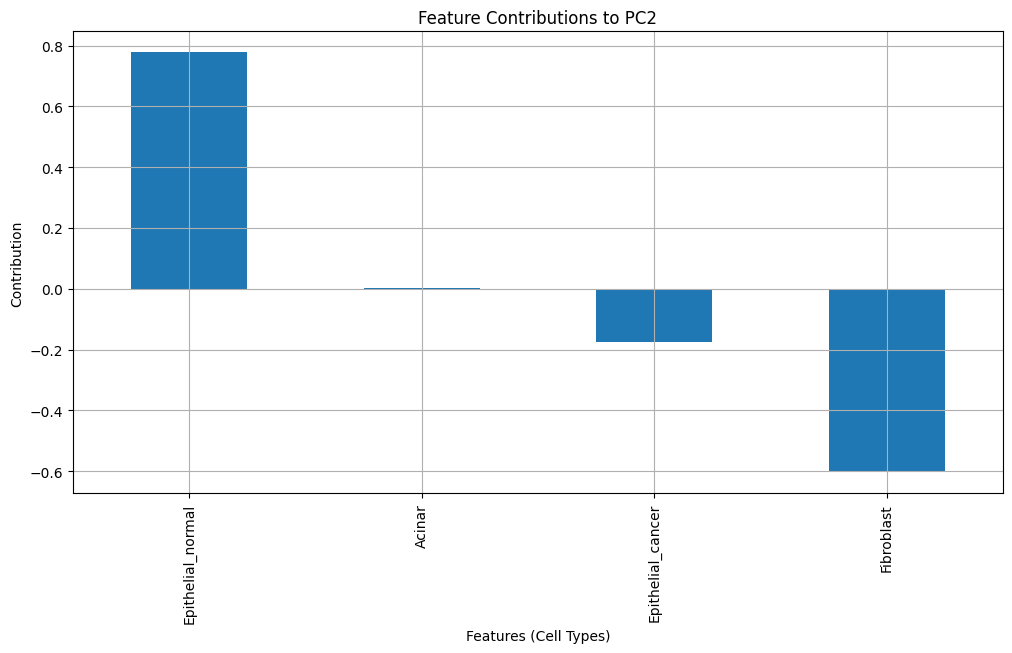

In [16]:
plt.figure(figsize=(12, 6))
loadings['PC2'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC2')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()

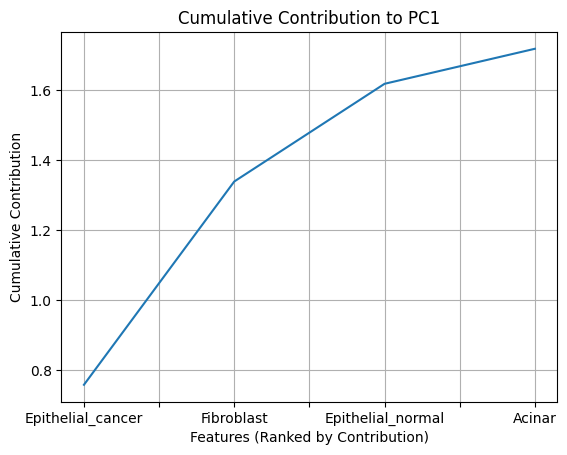

In [17]:
loadings['PC1'].abs().sort_values(ascending=False).cumsum().plot()
plt.title('Cumulative Contribution to PC1')
plt.xlabel('Features (Ranked by Contribution)')
plt.ylabel('Cumulative Contribution')
plt.grid()
plt.show()
